## 3. Build evalset

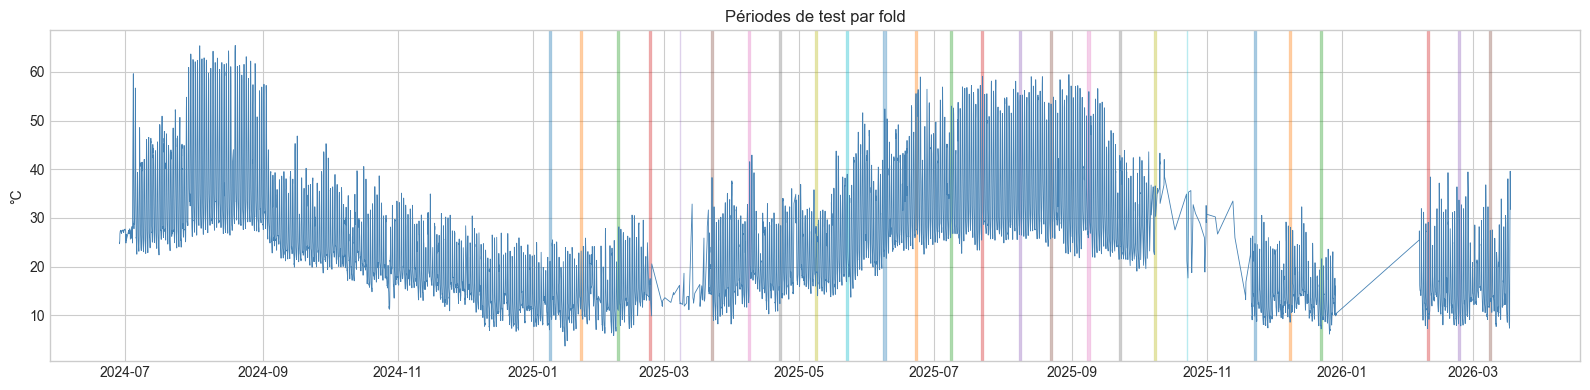

In [ ]:
import sys
from pathlib import Path

_parent = Path().resolve().parent
if str(_parent) not in sys.path:
    sys.path.insert(0, str(_parent))

import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import prepare_raw
from src.cv import bimonthly_splits
from src.plots import plot_fold_spans

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

import yaml
cfg = yaml.safe_load(Path('../config/config.yaml').read_text())

target   = cfg['target']
time_col = cfg['time_col']
path_data = cfg['path_data']
path_fold = cfg['path_fold']
test_horizon = cfg['test_horizon']
eval_startdate = cfg['eval_startdate']

df = pd.read_csv(path_data)
df = prepare_raw(df, datetime_col=time_col, unit="ms")

splits_info = bimonthly_splits(df, 
                               datetime_col=time_col, 
                               start=eval_startdate,
                               test_horizon=test_horizon,
                               save_path=path_fold
                               )

_ = plot_fold_spans(df, 
                    time_col=time_col, 
                    target_col=target)
plt.show()

In [2]:
splits_info

,Split,Month,Window,Train Size,Test Size,train_start,train_end,test_start,test_end
0,1,2025-01,semaine-2,4479,24,2024-06-28 11:00:00,2025-01-07 23:00:00,2025-01-08 00:00:00,2025-01-08 23:00:00
1,2,2025-01,semaine-4,4777,16,2024-06-28 11:00:00,2025-01-21 23:00:00,2025-01-22 00:00:00,2025-01-22 23:00:00
2,3,2025-02,semaine-2,5123,15,2024-06-28 11:00:00,2025-02-07 23:00:00,2025-02-08 00:00:00,2025-02-08 23:00:00
3,4,2025-02,semaine-4,5367,16,2024-06-28 11:00:00,2025-02-21 13:00:00,2025-02-22 06:00:00,2025-02-22 23:00:00
4,5,2025-03,semaine-2,5401,9,2024-06-28 11:00:00,2025-03-05 11:00:00,2025-03-08 01:00:00,2025-03-08 09:00:00
5,6,2025-03,semaine-4,5463,24,2024-06-28 11:00:00,2025-03-21 23:00:00,2025-03-22 00:00:00,2025-03-22 23:00:00
6,7,2025-04,semaine-2,5867,24,2024-06-28 11:00:00,2025-04-07 23:00:00,2025-04-08 00:00:00,2025-04-08 23:00:00
7,8,2025-04,semaine-4,6203,23,2024-06-28 11:00:00,2025-04-21 23:00:00,2025-04-22 00:00:00,2025-04-22 23:00:00
8,9,2025-05,semaine-2,6567,24,2024-06-28 11:00:00,2025-05-07 23:00:00,2025-05-08 00:00:00,2025-05-08 23:00:00
9,10,2025-05,semaine-4,6903,24,2024-06-28 11:00:00,2025-05-21 23:00:00,2025-05-22 00:00:00,2025-05-22 23:00:00
